# Sprint 9: Tomar decisiones de negocio basadas en datos

## Introducción
En este proyecto trabajaremos con los siguientes dataframes:

1.- Hipositesis, con las siguientes columnas;
Hypotheses: breves descripciones de las hipótesis
Reach: alcance del usuario, en una escala del uno a diez
Impact: impacto en los usuarios, en una escala del uno al diez
Confidence: confianza en la hipótesis, en una escala del uno al diez
Effort: los recursos necesarios para probar una hipótesis, en una escala del uno al diez. Cuanto mayor sea el valor Effort, más recursos requiere la prueba.

2.-orders, con las siguientes columnas:
transactionId: identificador de pedido
visitorId: identificador del usuario que realizó el pedido
date: fecha del pedido
revenue: ingresos del pedido
group: el grupo del test A/B al que pertenece el usuario

3.-visits, con las siguientes columnas:
date: la fecha
group: grupo del test A/B
visits: el número de visitas en la fecha especificada para el grupo de test A/B especificado

Objetivo:
Seleccionar la prioridad de las hipotesis por medio de resultados, filtrando los datos de manera correcta previamente.

## Inicialización

In [1]:
# Cargar todas las librerías
from scipy import stats as st
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import math
import datetime as dt
import scipy.stats as stats

## Cargar los datos

In [2]:
hypotheses_df = pd.read_csv("/datasets/hypotheses_us.csv", sep= ";")
orders_df = pd.read_csv("/datasets/orders_us.csv")
visits_df = pd.read_csv("/datasets/visits_us.csv")

## Preparar los datos
### hypotheses_df

In [3]:
hypotheses_df

,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


Viendo todo el dataframe vemos que no hay valores ausentes o duplicados.

In [4]:
hypotheses_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


In [5]:
#cambiaremos las columnas a letras minúsculas
hypotheses_df.columns= hypotheses_df.columns.str.lower()

### orders_df

In [6]:
orders_df.head(5)

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


In [7]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB


In [8]:
#Cambiaremos el tipo de dato de la columna date y los group a tipo category
orders_df["date"] = pd.to_datetime(orders_df["date"])
orders_df["group"] = orders_df["group"].astype("category")

In [9]:
#buscamos valores duplicados
orders_df.duplicated().sum()

0

In [10]:
#buscamos valores ausentes
orders_df.isna().sum()

transactionId    0
visitorId        0
date             0
revenue          0
group            0
dtype: int64

In [11]:
#revisaremos si hay usuarios presentes en el grupo A y B

#Obtenemos los usuarios del grupo A
groupA_orders_user= orders_df[orders_df["group"]=="A"]

#obtenemos los usuarios unicos del grupo A
groupA_orders_unique_user = groupA_orders_user["visitorId"].unique()

#Obtenemos los usuarios del grupo B
groupB_orders_user = orders_df[orders_df["group"]=="B"]

#obtenemoslos usuarios unicos del grupo B
groupB_orders_unique_user = groupB_orders_user["visitorId"].unique()

#Revisamos cuales usuarios se encuentran en ambos grupos
Isin_both_groups_orders = groupB_orders_user["visitorId"].isin(groupA_orders_user["visitorId"])

#Revisamos los usuarios unicos repetidos en ambos grupos
unique_Isin_both_groups_orders = set(groupA_orders_unique_user).intersection(groupB_orders_unique_user)

In [12]:
print("Cantidad de usuarios presentes en ambos grupos es de:", len(unique_Isin_both_groups_orders))

Cantidad de usuarios presentes en ambos grupos es de: 58


Vemos que la cantidad de usuarios repetidos son 58, pero hay que revisar cuantos valores del dataframe estaríamos elimiando en caso de simplemente sacarlos. También revisaremos si hay alguna fecha constante en la que se estuvieron realizando las compras para poder identificar una causa.

In [13]:
#Creamos un dataframe con los usuarios repetidos
both_groups_orders_df = orders_df[orders_df["visitorId"].isin(unique_Isin_both_groups_orders)]

#Veremos si en la fecha hay alguna constante
both_groups_orders_df["date"].describe()

count                     181
unique                     31
top       2019-08-14 00:00:00
freq                       16
first     2019-08-01 00:00:00
last      2019-08-31 00:00:00
Name: date, dtype: object

no hay una fecha fija, son todos durante el mes de agosto. Ya sería hablar directamente con el usuario pero como también en total son 181 valores, el cual representa alrededor del 15% del dataframe (son 1197 valores en total). Aqui hablariamos con nuestro superior para saber como proceder, si asignamos arbitrariamente los grupos de cada quien o si tienen alguna forma de saber a donde corresponde a cada quien. 
En este caso eliminaremos las compras de estos usuarios.

In [14]:
#Creamos un dataframe excluyendo los usuarios presentes en ambos grupos
filtered_orders_df = orders_df[~orders_df["visitorId"].isin(unique_Isin_both_groups_orders)]

### visits_df

In [15]:
visits_df.head(5)

,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [16]:
visits_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


In [17]:
#Pasamos la columna date a tipo date y groups a tipo category
visits_df["date"] = pd.to_datetime(visits_df["date"])
visits_df["group"] = visits_df["group"].astype("category")

In [18]:
#Buscamos valores duplicados
visits_df.duplicated().sum()

0

In [19]:
#Buscamos valores ausentes
visits_df.isna().sum()

date      0
group     0
visits    0
dtype: int64

No encontramos valores ausentes ni duplicados.
Los dataframes ya se encuentran listos para trabajar en ellos.

## Priorizar hipótesis
### Metodo ICE
ICE = Impact x Confidence x Ease = Impact X Confidence / Effort

In [20]:
hypotheses_df["ICE"] = (hypotheses_df["impact"]
                      * hypotheses_df["confidence"]
                      / hypotheses_df["effort"]
                      )
ICE= (hypotheses_df[["hypothesis", "ICE"]].sort_values(by="ICE", 
                                                      ascending=False)
     )
ICE

,hypothesis,ICE
8,Launch a promotion that gives users discounts ...,16.200000
0,Add two new channels for attracting traffic. T...,13.333333
7,Add a subscription form to all the main pages....,11.200000
6,Show banners with current offers and sales on ...,8.000000
2,Add product recommendation blocks to the store...,7.000000
1,Launch your own delivery service. This will sh...,2.000000
5,Add a customer review page. This will increase...,1.333333
3,Change the category structure. This will incre...,1.125000
4,Change the background color on the main page. ...,1.000000


En este caso vemos que la hypothesis de lanzar una promoción de un descuento a usuarios tiene el mayor puntuaje, seguido por agregar dos nuevos canales y agregar una forma de subscripción.

Veamos que dice el RICE SCORE.

### Metodo RICE SCORE
RICE = Reach x Impact x Confidence / Effort

In [21]:
hypotheses_df["RICE"] = (hypotheses_df["ICE"]
                        *hypotheses_df["reach"]
                        )

In [22]:
RICE = (hypotheses_df[["hypothesis", "RICE"]].sort_values(by="RICE", 
                                                          ascending=False)
       )
RICE

,hypothesis,RICE
7,Add a subscription form to all the main pages....,112.0
2,Add product recommendation blocks to the store...,56.0
0,Add two new channels for attracting traffic. T...,40.0
6,Show banners with current offers and sales on ...,40.0
8,Launch a promotion that gives users discounts ...,16.2
3,Change the category structure. This will incre...,9.0
1,Launch your own delivery service. This will sh...,4.0
5,Add a customer review page. This will increase...,4.0
4,Change the background color on the main page. ...,3.0


Vemos que agregar una subscripción y agregar dos nuevos canales siguen presentes en el top 4, y hay dos nuevos que son agregar bloques de recomendación de producto y mostras banners con ofertas estan ahora en este top.

En el caso del descuento de usuarios, no se presento por su bajo score en alcance, esto puede ser por la empresa que por el momento no cuente con el inventario o capital para hacer este tipo de inversión y se encuentre fuera de su alcance por el momento.

Nos iremos con el orden de RICE, aunque con ICE algunos tuvieron un buen SCORE pero si la empresa no cuenta con la capital o el tiempo para esas hipótesis, puede ser contraproducente en lugar de generar un beneficio.

## Análisis de test A/B

### Representar gráficamente el ingreso acumulado por grupo

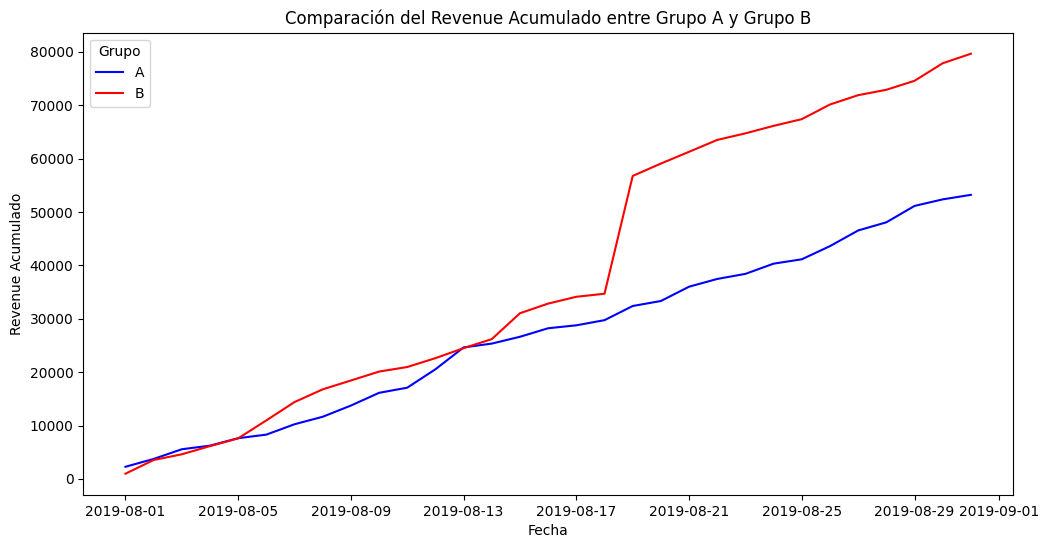

In [23]:
#Guardamos los valores del grupo A en un dataframe
groupA_orders = filtered_orders_df[filtered_orders_df["group"]=="A"]


#Guardamos los valores del grupo B en un dataframe
groupB_orders = filtered_orders_df[filtered_orders_df["group"]=="B"]

#Obtenemos el revenue acumulado por grupo
groupA_revenue = groupA_orders.groupby("date")["revenue"].sum().cumsum()
groupB_revenue = groupB_orders.groupby("date")["revenue"].sum().cumsum()

#Creamos una gráfica para comparar el revenue acumulado
plt.figure(figsize=(12, 6))
plt.plot(groupA_revenue.index, 
         groupA_revenue.values, 
         label="A", 
         color="blue"
        )
plt.plot(groupB_revenue.index,
         groupB_revenue.values,
         label="B",
         color="red"
        )

# Añadimos etiquetas y título
plt.xlabel("Fecha")
plt.ylabel("Revenue Acumulado")
plt.title("Comparación del Revenue Acumulado entre Grupo A y Grupo B")
plt.legend(title= "Grupo")


Ambos grupos iniciaron practicamente con el mismo crecimiento, el grupo A empezo a quedar atras empenzando el 5 de agosto y se reucpero el 13.
Aunque antes del 21 de agosto el grupo B dio un incremento drastico y siguo amuentando linealmente. Mientras que en el grupo A siempre hubo un crecimiento lineal.

### Representar gráficamente el tamaño de pedido promedio acumulado por grupo

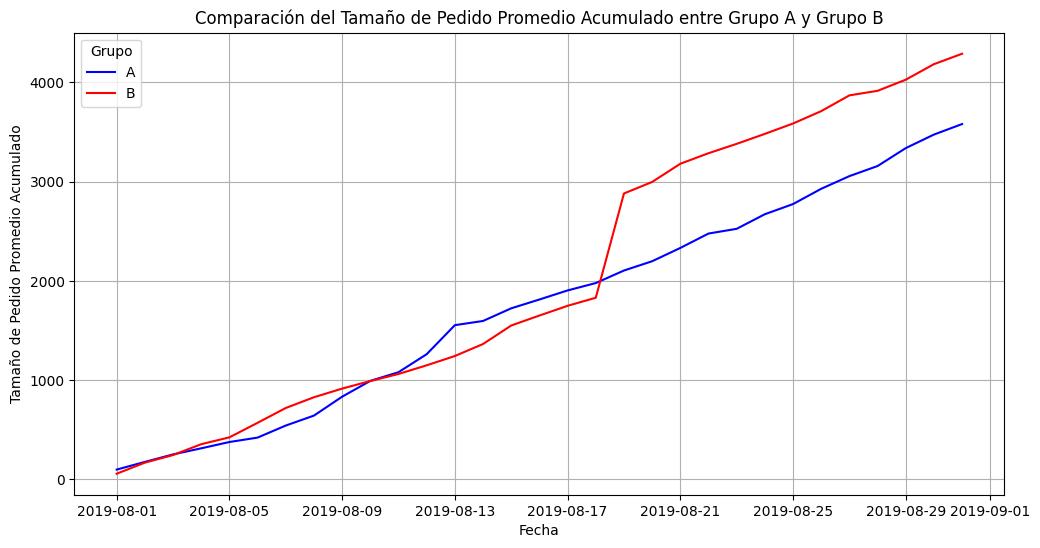

In [24]:
# Calcula el tamaño de pedido promedio para cada fecha y grupo
groupA_avg_order_size = (groupA_orders.groupby("date")
                         .apply(lambda x: 
                                x["revenue"].sum() 
                                / x["transactionId"].nunique()
                               )
                        )
groupB_avg_order_size = (groupB_orders.groupby("date")
                         .apply(lambda x: x["revenue"].sum() 
                                / x["transactionId"].nunique()
                               )
                        )

# Calcula el tamaño de pedido promedio acumulado para cada grupo
groupA_avg_order_size_cumsum = groupA_avg_order_size.cumsum()
groupB_avg_order_size_cumsum = groupB_avg_order_size.cumsum()

# Crea una gráfica para comparar el tamaño de pedido promedio acumulado
plt.figure(figsize=(12, 6))

# Plotea el tamaño de pedido promedio acumulado del grupo A
plt.plot(groupA_avg_order_size_cumsum.index, 
         groupA_avg_order_size_cumsum.values, 
         label="A", 
         color="blue"
        )

# Plotea el tamaño de pedido promedio acumulado del grupo B
plt.plot(groupB_avg_order_size_cumsum.index, 
         groupB_avg_order_size_cumsum.values, 
         label="B", 
         color="red"
        )

# Añade etiquetas y título
plt.xlabel("Fecha")
plt.ylabel("Tamaño de Pedido Promedio Acumulado")
plt.title("Comparación del Tamaño de Pedido Promedio Acumulado entre Grupo A y Grupo B")

# Añade la leyenda
plt.legend(title="Grupo")

# Añade una cuadrícula para mejorar la visualización
plt.grid(True)

# Muestra la gráfica
plt.show()

Ambos empezaron con un incremento similiar muy lineal, pero como también lo vimos en la gráfica anterior, antes del 21 de agosto hubo un incremento considerable en las ventas promedio del grupo B superando al grupo A y sigo con su incremento lineal.
Mientras que el grupo A siempre estuvo con un crecimiento lineal.

### Representa gráficamente la diferencia relativa en el tamaño de pedido promedio acumulado para el grupo B en comparación con el grupo A.

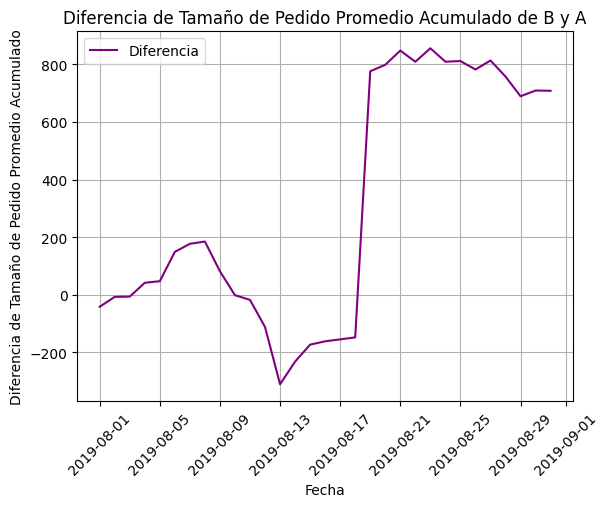

In [25]:
#Obtenemos la diferencia relativa en el tama entre el grupo A y B
groups_avg_revenue_diff = groupB_avg_order_size_cumsum - groupA_avg_order_size_cumsum

# Creamos un plot que muestre la diferencia del tamaño de pedido promedio acumulado del grupo B
plt.plot(groups_avg_revenue_diff .index, 
         groups_avg_revenue_diff .values, 
         label="Diferencia", 
         color="purple"
        )

# Añadimos etiquetas y título
plt.xlabel("Fecha")
plt.ylabel("Diferencia de Tamaño de Pedido Promedio Acumulado")
plt.title("Diferencia de Tamaño de Pedido Promedio Acumulado de B y A")

# Añadimos la leyenda
plt.legend()

# Añadimos una cuadrícula
plt.grid(True)

# Rotamos las etiquetas de las fechas
plt.xticks(rotation=45)

# Muestramos la gráfica
plt.show()

En la gráfica podemos ver que antes del 17 de agosto la diferencia entre el grupo A y B rondaba entre +- 200, pero a partir del 18 de Agosto hubo un gran incremento en B aumentando la diferencia entre ambos, llegando hasta una diferencia de +800, aunque despues del incremento se puede ver que la diferencia entre ambos empieza a disminuir lentamente.

### Calcula la tasa de conversión de cada grupo como la relación entre los pedidos y el número de visitas de cada día. Representa gráficamente las tasas de conversión diarias de los dos grupos y describe la diferencia. 

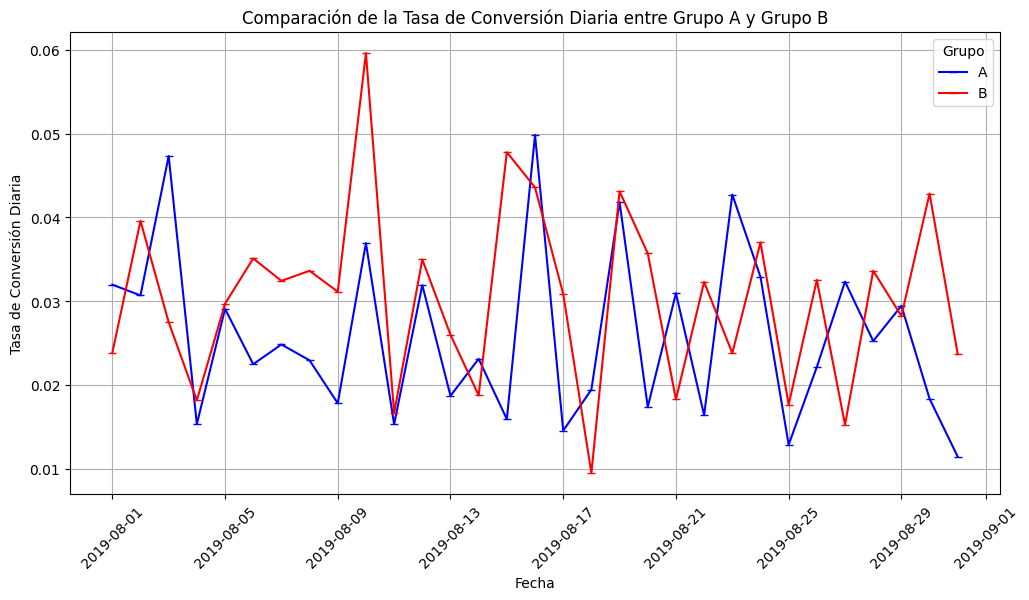

In [26]:
# Agrupamos por fecha y grupo en orders_df y contamos el número de pedidos únicos por día
orders_daily = (filtered_orders_df.groupby(["date", "group"])
                .agg(total_orders=("transactionId", "nunique") 
                    )
                .reset_index()
               )

# Agrupamos por fecha y grupo en visits_df y sumamos el total de visitas por día
visits_daily = (visits_df.groupby(["date", "group"])
                .agg(total_visits=("visits", "sum")
                    )
                .reset_index()
               )

# Unimos los DataFrames de pedidos y visitas en base a la fecha y el grupo
merged_df = pd.merge(orders_daily, 
                     visits_daily, 
                     on=["date", "group"]
                    )

# Calculamos la tasa de conversión diaria
merged_df["conversion_rate"] = (merged_df["total_orders"] 
                                / merged_df["total_visits"]
                               )

# Filtramos los datos para cada grupo
groupA_data = merged_df[merged_df["group"] == "A"]
groupB_data = merged_df[merged_df["group"] == "B"]

# Creamos una gráfica para comparar la tasa de conversión diaria
plt.figure(figsize=(12, 6))

# Hacemos plot de la tasa de conversión diaria del grupo A
plt.plot(groupA_data["date"],
         groupA_data["conversion_rate"], 
         label="A", 
         color="blue",
         marker="_"
        )

# Plotea la tasa de conversión diaria del grupo B
plt.plot(groupB_data["date"], 
         groupB_data["conversion_rate"], 
         label="B", 
         color="red", 
         marker="_"
        )
# Añadimos etiquetas y título
plt.xlabel("Fecha")
plt.ylabel("Tasa de Conversión Diaria")
plt.title("Comparación de la Tasa de Conversión Diaria entre Grupo A y Grupo B")

# Añadimos la leyenda
plt.legend(title="Grupo")

# Añadimos una cuadrícula
plt.grid(True)

# Rotamos las etiquetas de las fechas
plt.xticks(rotation=45)

# Muestramos la gráfica
plt.show()

En esta grafica podemos ver que la tasa de conversión entre ambos grupos ronda en su mayoría igual, solo ciertos lapsos donde B supera A, como del 5 de agosto al 9 de agosto hubo un aumento en la tasa por parte de B, luego regreso a ser similar a A, ya para el 29 de agosto parece que A empieza a bajar mientras que B subió y empezo a bajar.

### Traza un gráfico de dispersión del número de pedidos por usuario

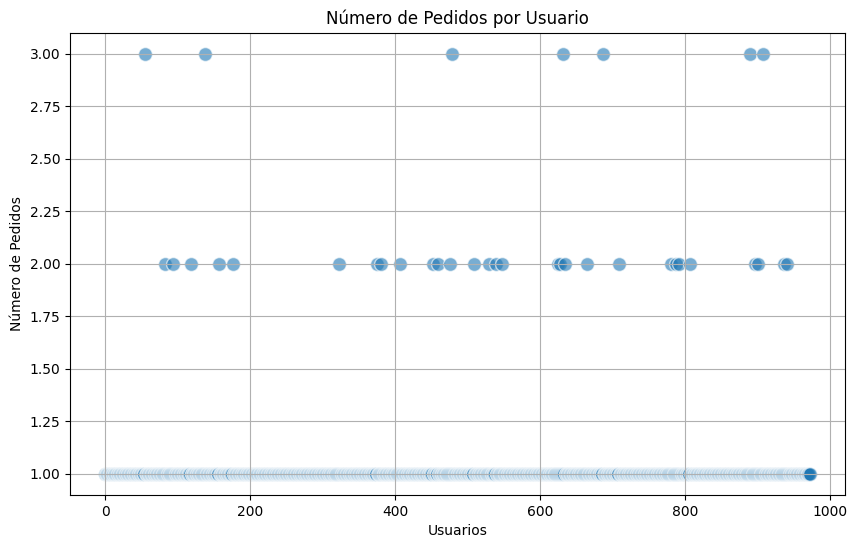

In [27]:
# Contamos el número de pedidos por usuario
orders_per_user = (filtered_orders_df.groupby("visitorId")
                   .agg(num_orders=("transactionId", "nunique")).reset_index()
                  )

# Trazamos gráfico de dispersión del número de pedidos por usuario
plt.figure(figsize=(10, 6))

# Obtenemos el valor del eje X
x_values = pd.Series(range(0, 
                           len(orders_per_user["num_orders"])
                          )
                    )


# Creamos un scatter del número de pedidos por usuario
plt.scatter(x_values, 
            orders_per_user["num_orders"], 
            alpha=0.6, 
            edgecolors='w', 
            s=100)

# Añadimos etiquetas y título
plt.xlabel("Usuarios")
plt.ylabel("Número de Pedidos")
plt.title("Número de Pedidos por Usuario")

# Añadimos una cuadrícula
plt.grid(True)

# Mostramos la gráfica
plt.show()

Para esta grafica use el dataframe de orders sin el filtro de quitar los usuarios que esten presentes en ambos grupos, ya que no se está solicitando hacerló por grupos.
La mayoría de usuarios realizan un pedido y a lo mucho se hacen 11 pedidos. No se si haya un error en el sistema que este generando nuevos Id a usuarios que ya tenían Id o si realmente son en su mayoría que nomás realizan una compra. Es algo que si se debería de verificar.

### Calculamos los percentiles 95 y 99 para el número de pedidos por usuario.

In [28]:
#obtenemos los percentiles de 95 y 99 de la cantidad de pedidos por usuario
np.percentile(orders_per_user["num_orders"], 
              [95,99]
             )

array([1., 2.])

Con los resultados obtenidos podemos decir que no mas del 5% de usuarios realizan 2 pedidos y no mas del 1% de usuarios realizan mas de 4 pedidos.
Si se hace algo raro que sean tan pocos por persona, pero también depende del tipo de mercado y clientes.

### Trazamos un gráfico de dispersión de los precios de los pedidos.

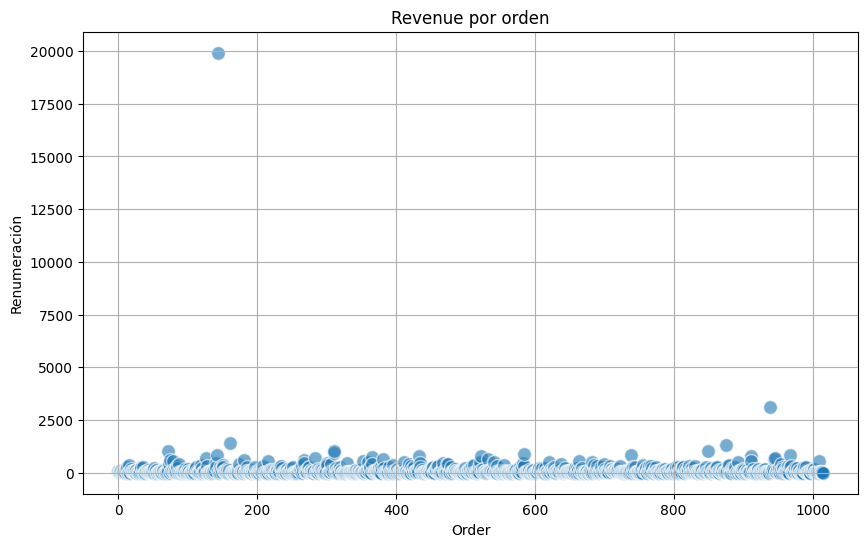

In [29]:
# Contamos el número de pedidos por usuario
revenue_per_order = (filtered_orders_df.groupby("transactionId")
                   .agg(total_revenue=("revenue", "sum")).reset_index()
                  )

# Trazamos gráfico de dispersión de la renumeración por pedido
plt.figure(figsize=(10, 6))

# Obtenemos el valor del eje X
x_values = pd.Series(range(0, 
                           len(revenue_per_order["transactionId"])
                          )
                    )


# Creamos un scatter del número de pedidos por usuario
plt.scatter(x_values, 
            revenue_per_order["total_revenue"], 
            alpha=0.6, 
            edgecolors='w', 
            s=100)

# Añadimos etiquetas y título
plt.xlabel("Order")
plt.ylabel("Renumeración")
plt.title("Revenue por orden")

# Añadimos una cuadrícula
plt.grid(True)

# Mostramos la gráfica
plt.show()

A simple vista vemos que la mayoría se encuentre debajo de los 2500, con solo un par arriba y uno de ellos llegando a los 20,000. Aqui vemos claramente dos anomalías pero veamos ya en número los percentiles.

### Calcula los percentiles 95 y 99 de los precios de los pedidos. 

In [30]:
np.percentile(revenue_per_order["total_revenue"], 
              [95,99]
             )

array([414.275, 830.3  ])

Menos del 5% compraron mas de 414 y menos del 1% compraron 830.3. No podemos decir si es bueno o malo si realmente conocer el tipo de mercado.

### Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos en bruto.

In [31]:
#Obtenemos las compras por usuario del grupo A
ordersByUsersA = (filtered_orders_df[filtered_orders_df["group"]=="A"]
                  .groupby("visitorId", 
                           as_index=False)
                  .agg({ "transactionId": pd.Series.nunique}
                      )
                 )
ordersByUsersA.columns = ["visitorId", "orders"]

#Obtenemos las compras por usuario del grupo B
ordersByUsersB = (filtered_orders_df[filtered_orders_df["group"]=="B"]
                  .groupby("visitorId", 
                           as_index=False)
                  .agg({ "transactionId": pd.Series.nunique}
                      )
                 )
ordersByUsersB.columns = ["visitorId", "orders"]

#obtenemos las muestras de conversiones en relacion compras y visitas
sampleA = (pd.concat([ordersByUsersA["orders"],
                      pd.Series(0, 
                                index=np.arange(visits_df[visits_df["group"]=="A"]["visits"].sum() 
                                                - len(ordersByUsersA["orders"])),
                                name="orders")],
                     axis=0)
          )
sampleB = (pd.concat([ordersByUsersB["orders"],
                      pd.Series(0, 
                                index=np.arange(visits_df[visits_df["group"]=="B"]["visits"].sum() 
                                                - len(ordersByUsersB["orders"])),
                                name="orders")],
                     axis=0)
          )


print("{0:.3f}".format(stats.mannwhitneyu(sampleA, sampleB)[1]))

print("{0:.3f}".format(sampleB.mean()/sampleA.mean()-1))


0.011
0.160


Un resultado de 0.011, esto nos dice que la diferencia estadistica entre ambos grupos es significativa (ya que es menor que alpha de 0.05), esto quiere decir que las diferencias que vimos no fueron al azar.

Y tenemos una diferencia del 16 con el siguiente resultado, lo que dependiendo del objetivo de la prueba, puede ser un diferencia significante positiva.

#### Nota:
No se si por datos en bruto se refiera a los datos sin filtrar las personas que están presentes en ambos grupos y los pedidos con valores atipicos o solo sin filtrar los valores atipicos. Use eliminando los usuarios en ambos grupos

### Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos en bruto.

In [32]:
# Calculamos el tamaño promedio de pedido por usuario
avg_order_sizeA = (groupA_orders_user.groupby("visitorId", as_index=False)
                    .agg({"revenue": "mean"}
                        )
                   )
avg_order_sizeA.columns = ["visitorId", "avg_order_size"]

avg_order_sizeB = (groupB_orders_user.groupby("visitorId", as_index=False)
                    .agg({"revenue": "mean"}
                        )
                   )
avg_order_sizeB.columns = ["visitorId", "avg_order_size"]

# Creamos muestras con tamaño promedio de pedidos y rellenamos con ceros
sampleA = (pd.concat([avg_order_sizeA["avg_order_size"],
                      pd.Series(0, 
                                index=np.arange(visits_df[visits_df["group"] == "A"]["visits"].sum() 
                                                - len(avg_order_sizeA["avg_order_size"])),
                                name="avg_order_size")],
                     axis=0)
          )

sampleB = (pd.concat([avg_order_sizeB["avg_order_size"],
                      pd.Series(0, 
                                index=np.arange(visits_df[visits_df["group"] == "B"]["visits"].sum() 
                                                - len(avg_order_sizeB["avg_order_size"])),
                                name="avg_order_size")],
                     axis=0)
          )
#Realizamos una Prueba Estadística

print("{0:.3f}".format(stats.mannwhitneyu(sampleA, sampleB)[1]))

print("{0:.3f}".format(sampleB.mean()/sampleA.mean()-1))


0.017
0.450


Un resultado de 0.017, esto nos dice que la diferencia estadistica entre ambos grupos es significativa (ya que es menor que alpha de 0.05), esto quiere decir que las diferencias que vimos no fueron al azar.

Y tenemos una diferencia del 45% con el siguiente resultado,esto es una diferencia significativa, quiere decir que hubo un aumento significativo en las compras promedio en el grupo B.

### Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos filtrados.

In [33]:
#Obtenemos usuarios con muchos pedidos, mas de 2 pedidos
usersWithManyOrders = (pd.concat([ordersByUsersA[ordersByUsersA["orders"] > 2]["visitorId"],
                                 ordersByUsersB[ordersByUsersB["orders"] > 2]["visitorId"]],
                                axis = 0)
                      )
#Obtenemos usuarios con compras atipicas, mas de 450 en monto
usersWithExpensiveOrders = filtered_orders_df[filtered_orders_df["revenue"] > 450]["visitorId"]

#Obtenemos los usuarios atipicos utilizando los valores anteriores
abnormalUsers = (pd.concat([usersWithManyOrders, 
                            usersWithExpensiveOrders], 
                           axis = 0).drop_duplicates().sort_values()
                )

#Obtenemos la muestra del grupo A filtrando pedidos atipicos
sampleAFiltered = (pd.concat([ordersByUsersA[np.logical_not(ordersByUsersA["visitorId"]
                                                            .isin(abnormalUsers))]["orders"],
                              pd.Series(0, 
                                        index=np.arange(visits_df[visits_df["group"]=="A"]["visits"].sum() 
                                                        - len(ordersByUsersA['orders'])),
                                        name='orders')]
                             ,axis=0
                            )
                  )

sampleBFiltered = (pd.concat([ordersByUsersB[np.logical_not(ordersByUsersB["visitorId"]
                                                            .isin(abnormalUsers))]["orders"],
                              pd.Series(0, 
                                        index=np.arange(visits_df[visits_df["group"]=='B']["visits"].sum() 
                                                        - len(ordersByUsersB["orders"])),
                                        name="orders")],
                             axis=0
                            )
                  )
print("{0:.3f}".format(stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]))
print("{0:.3f}".format(sampleBFiltered.mean()/sampleAFiltered.mean()-1))


0.010
0.188


Recordando que antes de usar el filtro la diferencia estadistica fue de 0.011 y pasamos a 0.010, asi que la diferencia fue muy minima y pasamos del 16 a 18.8, asi que aun quitando los valores atipicos nos encontramos en un porcentaje de diferencia mayor, queriendo decir que la prueba B si tuvo exito.

### Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos filtrados.

In [34]:
# Crear la muestra para el grupo A
filtered_ordersA= avg_order_sizeA[~avg_order_sizeA["visitorId"].isin(abnormalUsers)]["avg_order_size"]
num_visits_A = visits_df[visits_df["group"] == "A"]["visits"].sum()
num_orders_A = len(filtered_ordersA)
sampleAfiltered = pd.concat([
    filtered_ordersA,
    pd.Series(0, index=np.arange(num_visits_A - num_orders_A), 
              name="avg_order_size")
], axis=0)

# Creamos la muestra filtrada para el grupo B
filtered_ordersB= avg_order_sizeB[~avg_order_sizeB["visitorId"].isin(abnormalUsers)]["avg_order_size"]
num_visits_B = visits_df[visits_df["group"] == "B"]["visits"].sum()
num_orders_B = len(filtered_ordersB)
sampleBfiltered = pd.concat([
    filtered_ordersB,
    pd.Series(0, index=np.arange(num_visits_B - num_orders_B), 
              name="avg_order_size")
], axis=0)

print("{0:.3f}".format(stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]))
print("{0:.3f}".format(sampleBFiltered.mean()/sampleAFiltered.mean()-1))

0.010
0.188


Recordando que sin filtrar los datos obtuvimos 0.010 y con filtro un 0.010, este resultado no tuvo un cambio.

El que si hubo una gran diferencia fue el resultado de 45% a 18.8%, si hubo una gran diferencia y se puede ver como el resultado fue afectado por los valores atipicos previamente. Aunque un 18.8% de incremento aún suena bien pero depende de la meta.

### Toma una decisión basada en los resultados de la prueba. 

Basado en los resultados con los datos filtrados, podemos deducir que la prueba B fue significativa mayor a la prueba A, y deberian ir por esa opción. Si desean buscar un mejor resultado, ya deben de compararlo con esta prueba e ir aumentando a partir de ella.